In [41]:
!pip install git+https://github.com/google-deepmind/alphagenome_research.git
!pip install pyfaidx numpy torch

import os
import numpy as np
import torch
from pyfaidx import Fasta

import alphagenome
print(f"AlphaGenome version: {alphagenome.__version__}")

  Cloning https://github.com/google-deepmind/alphagenome_research.git to /tmp/pip-req-build-mxl333o1
  Running command git clone --filter=blob:none --quiet https://github.com/google-deepmind/alphagenome_research.git /tmp/pip-req-build-mxl333o1
  Resolved https://github.com/google-deepmind/alphagenome_research.git to commit 455009019acd4c816873d648404ffef2d506606c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
AlphaGenome version: 0.6.1


In [42]:
if not os.path.exists("chr22.fa"):
    !wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr22.fa.gz
    !gunzip chr22.fa.gz

def segment_genome(fasta_file, L):
    genome_data = Fasta(fasta_file)
    loci = []
    for chrom in genome_data.keys():
        length = len(genome_data[chrom])
        for start in range(0, length - L + 1, L):
            seq = genome_data[chrom][start:start+L].seq.upper()
            if seq.count('N') / L < 0.2:
                loci.append(seq)
    return loci

L = 1048576  # 1Mb segments
sequences = segment_genome('chr22.fa', L)
print(f"Total loci generated (N): {len(sequences)}")

Total loci generated (N): 35


In [43]:
from alphagenome.models import dna_client
from google.colab import userdata

try:
    API_KEY = userdata.get('ALPHAGENOME_API_KEY')
except:
    API_KEY = "YOUR_API_KEY_HERE"

try:
    version_to_use = dna_client.ModelVersion.ALL_FOLDS

    model = dna_client.create(
        model_version=version_to_use,
        api_key=API_KEY
    )
except Exception as e:
    print(f"{e}")

In [44]:
L = 131072

def segment_genome_fixed(fasta_file, L):
    genome_data = Fasta(fasta_file)
    loci = []
    for chrom in genome_data.keys():
        length = len(genome_data[chrom])
        # Force segments to be exactly L
        for start in range(0, length - L + 1, L):
            seq = genome_data[chrom][start:start+L].seq.upper()
            if seq.count('N') / L < 0.1: # Only keep high-quality sequences
                loci.append(seq)
    return loci

sequences = segment_genome_fixed('chr22.fa', L)
print(f"Generated {len(sequences)} loci of length {L} bp.")

Generated 285 loci of length 131072 bp.


In [46]:
import numpy as np

requested = [dna_client.OutputType.CHIP_TF]
ontology = []
N = len(sequences)
K = None

print(f"Encoding {N} loci...")

for i, seq in enumerate(sequences):
    response = model.predict_sequence(
        sequence=seq,
        requested_outputs=requested,
        ontology_terms=ontology
    )

    track_obj = response.chip_tf
    data = track_obj.values

    if data is not None and data.size > 0:
        locus_vector = np.mean(data, axis=0)
    else:
        if K is not None:
            locus_vector = np.zeros(K.shape[1])
        else:
            continue

    if K is None:
        d = locus_vector.shape[0]
        K = np.zeros((N, d))
    K[i] = locus_vector

    if (i + 1) % 10 == 0:
        print(f"Progress: {i+1}/{N} loci processed.")

print(f"Final Shape: {K.shape}")
np.save('K_matrix_final.npy', K)
print("Matrix saved to 'K_matrix_final.npy'")

Encoding 285 loci...
Progress: 10/285 loci processed.
Progress: 20/285 loci processed.
Progress: 30/285 loci processed.
Progress: 40/285 loci processed.
Progress: 50/285 loci processed.
Progress: 60/285 loci processed.
Progress: 70/285 loci processed.
Progress: 80/285 loci processed.
Progress: 90/285 loci processed.
Progress: 100/285 loci processed.
Progress: 110/285 loci processed.
Progress: 120/285 loci processed.
Progress: 130/285 loci processed.
Progress: 140/285 loci processed.
Progress: 150/285 loci processed.
Progress: 160/285 loci processed.
Progress: 170/285 loci processed.
Progress: 180/285 loci processed.
Progress: 190/285 loci processed.
Progress: 200/285 loci processed.
Progress: 210/285 loci processed.
Progress: 220/285 loci processed.
Progress: 230/285 loci processed.
Progress: 240/285 loci processed.
Progress: 250/285 loci processed.
Progress: 260/285 loci processed.
Progress: 270/285 loci processed.
Progress: 280/285 loci processed.
Final Shape: (285, 1617)
Matrix save

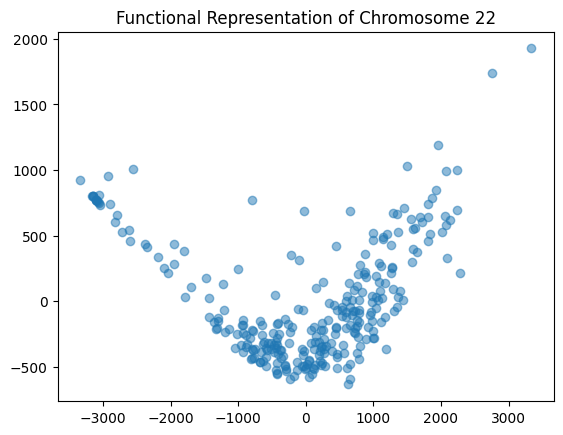

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
K_2d = pca.fit_transform(K)
plt.scatter(K_2d[:, 0], K_2d[:, 1], alpha=0.5)
plt.title("Functional Representation of Chromosome 22")
plt.show()

In [50]:
!pip install scanpy anndata louvain

!pip install git+https://github.com/JiekaiLab/scarf.git

  Cloning https://github.com/JiekaiLab/scarf.git to /tmp/pip-req-build-o20t8s9l
  Running command git clone --filter=blob:none --quiet https://github.com/JiekaiLab/scarf.git /tmp/pip-req-build-o20t8s9l
  Resolved https://github.com/JiekaiLab/scarf.git to commit 9efd249e08b04e6441eb3c111ec48fc38a769a9d
ERROR: git+https://github.com/JiekaiLab/scarf.git does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
